# Membrane height fluctuations: recovering $q^{-4}$

A flat fluid membrane in the Monge gauge has the Helfrich free energy

$$E \;=\; \tfrac12 \int \mathrm{d}A \left[\, \kappa_c (\nabla^2 h)^2 + \sigma (\nabla h)^2 \,\right]$$

which, on a periodic box of projected area $A$ with Fourier modes
$h(\mathbf r) = \sum_{\mathbf q} h_{\mathbf q}\, e^{i\mathbf q\cdot\mathbf r}$ and
$h_{\mathbf q} = A^{-1}\!\int \mathrm{d}^2r\; h(\mathbf r)\, e^{-i\mathbf q\cdot\mathbf r}$,
diagonalises to $E = \frac{A}{2}\sum_{\mathbf q}(\kappa_c q^4 + \sigma q^2)|h_{\mathbf q}|^2$.
Equipartition then gives the relation this notebook measures:

$$\boxed{\;\langle |h_{\mathbf q}|^2\rangle \;=\; \frac{k_BT}{A\,(\kappa_c q^4 + \sigma q^2)}\;}$$

With no tension that is a straight line of slope $-4$ on a log–log plot, whose
intercept fixes $\kappa_c$.

The second half of this notebook looks at the *dynamics* —
$\langle h_{\mathbf q}(t)\, h^*_{\mathbf q}(t+\tau)\rangle$.

### Notes

**Monge Gauge and minimum horizontal drift assumption**. In this analysis, the
membrane is represented in Monge Gauge $z(x,y)$. And no-resampling happens: the
vertices are assumed to be quasi-stable sampling points and minimum horizontal
drift throughout the simulation (which is valid in a flat simulation; from the
results, x,y drifts are >6 orders of magnitude smaller than z drift)

**Conventions used throughout.** Every mode is plotted individually; nothing is
binned in $|q|$. Error bars are block estimates from the time series of that
same mode: the trajectory is cut into equal blocks, the quantity is measured in
each, and the bar is the standard error over blocks. Conjugate modes
$\mathbf q$ and $-\mathbf q$ are the same measurement for a real field
($|h_{-\mathbf q}|^2 \equiv |h_{\mathbf q}|^2$ frame by frame), so one of each pair
is kept rather than plotting the same number twice.

**Needs** `analysis/membrane_spectrum.py`, which
carries the parts that are easy to get wrong: the zig-zag lattice geometry, the
periodic tile, the exact DFT on the true vertex positions, and the
reciprocal-lattice $q$ grid. See `docs/fluctuation_spectrum.md`.

In [1]:
import os
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle


def find_repo_root(start=None):
    """The SLIMED checkout this notebook sits in, wherever it is run from."""
    here = Path(start or Path.cwd()).resolve()
    for d in (here, *here.parents):
        if (d / "CMakeLists.txt").is_file() and (d / "EXEs").is_dir():
            return d
    raise RuntimeError(f"no SLIMED checkout at or above {here}")


REPO = find_repo_root()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "analysis"))
import membrane_spectrum as ms

# Where the dynamics runs live.  Section 0 puts them here, made by this
# machine's own OpenMP CPU build.  Set SLIMED_RUNS to analyse runs made
# somewhere else instead -- on a cluster, say -- and section 0 will keep any
# it finds already finished.
RUNS = Path(os.environ.get("SLIMED_RUNS", Path.home() / "slimed_runs"))
RUNS.mkdir(parents=True, exist_ok=True)

KBT = 4.17          # pN.nm, as in input.params
NBLOCK = 8          # blocks used for every error bar in this notebook

print("repo:", REPO)
print("runs:", RUNS)
print(sorted(p.name for p in RUNS.iterdir() if p.is_dir()))

repo: /Users/yue/Workspace/SLIMED
runs: /Users/yue/slimed_runs
[]


In [2]:
# --- slide styling ----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "font.size": 17,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.labelspacing": 0.35,
    "lines.linewidth": 2.6,
    "lines.markersize": 9,
    "axes.linewidth": 1.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 7, "ytick.major.size": 7,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "errorbar.capsize": 3,
})

TEAL  = "#0f766e"
BRICK = "#b1442a"
OCHRE = "#a07a12"
INK   = "#111827"
GREY  = "#8d9794"


def nice_logx(*axes):
    """Plain numbers on a log axis: 0.1, 0.2, 0.3 ... not 2 x 10^-1."""
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    fmt = FuncFormatter(lambda v, _: f"{v:g}")
    cand = [m * 10.0 ** d for d in range(-6, 6) for m in (1, 1.5, 2, 3, 5, 7)]
    for ax in axes:
        lo, hi = ax.get_xlim()
        ticks = [c for c in cand if lo <= c <= hi]
        if len(ticks) >= 3:
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.xaxis.set_major_formatter(fmt)


def unique_modes(lat):
    """One representative per conjugate pair, and never the q = 0 mode.

    For a real height field |h_{-q}|^2 equals |h_q|^2 in every frame, so the
    two are the same datapoint, not two.
    """
    keep = np.zeros((lat.ny, lat.nx), bool)
    seen = set()
    for iy in range(lat.ny):
        for ix in range(lat.nx):
            if (iy, ix) == (0, 0):
                continue
            if ((-iy) % lat.ny, (-ix) % lat.nx) in seen:
                continue
            seen.add((iy, ix))
            keep[iy, ix] = True
    return keep


# --- how far up in q the continuum law may be fitted ------------------------
# q*dFaceX = pi is the Nyquist wavevector of the mesh spacing, so pi/2 is half
# of it: four mesh cells per wavelength.  That the discretisation is still
# faithful there is measured, not assumed -- tests/test_continuum_limit.cpp
# puts an exact plane wave on the control net, reads the bending energy the
# production code returns, and refers the stiffness to the limit surface.
QDX_MAX = np.pi / 2

# q*dFaceX -> K_S(q) / (A kc q^4), from tests/test_continuum_limit.cpp.
# A function of q*dFaceX alone: the same numbers come back on a mesh twice as
# fine.  1 where the mesh is faithful; 0.995 at pi/2.
FORM_FACTOR = np.array([
    [0.000, 1.0000], [0.403, 1.0000], [0.603, 0.9999], [0.898, 0.9992],
    [1.209, 0.9979], [1.346, 0.9953], [1.612, 0.9919], [1.810, 0.9845],
    [2.015, 0.9754], [2.244, 0.9497], [2.418, 0.9355], [2.821, 0.8509],
    [3.225, 0.7002],
])


def form_factor(q, d_face_x):
    """How much softer than the continuum this mesh is at wavevector q."""
    return np.interp(q * d_face_x, FORM_FACTOR[:, 0], FORM_FACTOR[:, 1])


print(f"continuum window: q*dFaceX <= pi/2 = {QDX_MAX:.4f}"
      f"  (lambda >= 4 cells; lattice error {1-form_factor(QDX_MAX, 1.0):.1%})")

continuum window: q*dFaceX <= pi/2 = 1.5708  (lambda >= 4 cells; lattice error 0.8%)


---
## 0. The runs on the CPU

Everything below is measured from three trajectories of the same 100 nm
periodic box. They are produced by CPU build
with OpenMP on — `cmake -DSLIMED_ENABLE_OPENMP=ON`, and `forceBackend = cpu` in
every `input.params`.

| run | what it is | steps | frame every |
| --- | --- | ---: | ---: |
| `pure_a` | $\mu_S=0$, the equilibrium spectrum | 800 000 | 100 |
| `tension` | $\mu_S=250$ pN/nm, section 6 | 800 000 | 100 |
| `fast_test` | $\mu_S=0$, for the fast modes in section 7 | 60 000 | 1 |

`run_dynamics_flat` takes no arguments — it reads `./input.params` and writes
fixed output names — so each run gets its own directory and is launched from
inside it.

**Note** : OpenMP threading buys little here (the dense `surface2mesh` multiply
dominates and does not thread, see the performance note in
`docs/fluctuation_spectrum.md`), so the three runs are started as concurrent
processes with a few threads each rather than one after another.

Expect roughly **40 minutes** and **2 GB**.

In [3]:
BUILD = REPO / "build-omp"
EXE = BUILD / "bin" / "membrane_dynamics"

# 1.0 is the length the measurement actually needs; see the note above.  It
# shortens the two long runs only -- fast_test is three minutes either way,
# and section 7 has no fast modes to time without it.
SCALE = float(os.environ.get("SLIMED_STEPS_SCALE", 1.0))

# A 100 nm box on a 5 nm mesh: nFace 20 x 24, so a 14 x 18 periodic tile.
COMMON = {
    "boundaryType": "Periodic",
    "isFlat": "true",
    "lFace": 5.0,
    "sideX": 100.0,
    "sideY": 100.0,
    "kcMembraneBending": 83.4,      # 20 kT
    "c0Membrane": 0.0,
    "uvVolumeConstraint": 0.0,
    "isGlobalConstraint": "true",
    "setRelaxAreaToDefault": "true",
    "KBT": KBT,
    "timeStep": 0.002,              # us
    "diffConst": 1.0,               # nm^2/us
    "forceBackend": "cpu",          # the CPU loops, not the CUDA backend
    "fdtConsistentSurfaceUpdate": "true",    # section 3 of the doc: all three
    "integratePeriodicDuplicates": "false",  # fixes on
    "thermalFluctuationEnabled": "false",    # Brownian dynamics, not Metropolis
    "isInsertionIncluded": "false",
    "isEnergyHarmonicBondIncluded": "false",
    "isGagScaffoldingEnergyIncluded": "false",
    "isIdealizedProteinLatticeEnergyIncluded": "false",
    "meshpointOutput": "true",
    "xyzOutput": "false",
    "VERBOSE_MODE": "false",
}

SPECS = {
    "pure_a":      {"usMembraneStretching": 0.0,   "maxIterations": 800_000,
                    "meshpointOutputInterval": 100, "randomSeed": 101},
    "tension":     {"usMembraneStretching": 250.0, "maxIterations": 800_000,
                    "meshpointOutputInterval": 100, "randomSeed": 202},
    "fast_test": {"usMembraneStretching": 0.0,   "maxIterations": 60_000,
                    "meshpointOutputInterval": 1,   "randomSeed": 303},
}
SCALABLE = ("pure_a", "tension")


def openmp_binary():
    """build-omp/bin/membrane_dynamics, configuring and building if need be."""
    cache = BUILD / "CMakeCache.txt"
    on = cache.is_file() and "SLIMED_ENABLE_OPENMP:BOOL=ON" in cache.read_text()
    if on and EXE.is_file():
        return EXE
    if not on:
        cmake("-S", str(REPO), "-B", str(BUILD),
              "-DSLIMED_ENABLE_OPENMP=ON", "-DCMAKE_BUILD_TYPE=Release")
    cmake("--build", str(BUILD), "--target", "membrane_dynamics",
          "-j", str(os.cpu_count() or 4))
    return EXE


def cmake(*args):
    p = subprocess.run(["cmake", *args], capture_output=True, text=True)
    if p.returncode:
        raise RuntimeError("cmake " + " ".join(args) + " failed:\n"
                           + (p.stdout + p.stderr)[-2000:])


def params_text(name, spec):
    p = dict(COMMON, **spec)
    if name in SCALABLE:
        p["maxIterations"] = max(2000, int(p["maxIterations"] * SCALE))
    return "".join(f"{k} = {v}\n" for k, v in p.items())


MARKER = ".made-by-this-notebook"


def state(d, text):
    """"missing", "finished", "stale", or "foreign".

    A run this notebook made itself is remade when the parameters above
    change; one it did not make is never touched, whatever it holds.
    SLIMED_RUNS may well point at trajectories from somewhere else, and those
    are exactly the ones worth keeping.
    """
    if not ((d / "inputvertex_final.csv").is_file()
            and (d / "meshpointinput.csv").is_file()):
        return "missing"
    pf = d / "input.params"
    if pf.is_file() and pf.read_text() == text:
        return "finished"
    return "stale" if (d / MARKER).is_file() else "foreign"


def last_iteration(log):
    """The step count the run is on, from the tail of its own stdout."""
    try:
        with open(log, "rb") as f:
            f.seek(0, os.SEEK_END)
            f.seek(max(0, f.tell() - 8192))
            hits = re.findall(rb"ITERATION:(\d+)", f.read())
        return int(hits[-1]) + 1 if hits else 0
    except OSError:
        return 0


def generate(specs=SPECS, poll=15.0):
    exe = openmp_binary()
    threads = max(1, min(4, (os.cpu_count() or 4) // max(1, len(specs))))
    jobs = {}
    for name, spec in specs.items():
        d = RUNS / name
        d.mkdir(parents=True, exist_ok=True)
        text = params_text(name, spec)
        st = state(d, text)
        if st in ("finished", "foreign"):
            note = "" if st == "finished" else (
                "  (not made here, and its parameters differ -- "
                "delete the directory to regenerate)")
            print(f"{name:12s} finished already, keeping it{note}")
            continue
        if st == "stale":
            print(f"{name:12s} parameters changed, running it again")
        (d / "input.params").write_text(text)
        (d / MARKER).touch()
        for stale in ("inputvertex_final.csv", "meshpointinput.csv",
                      "surfacepointinput.csv"):
            (d / stale).unlink(missing_ok=True)
        log = open(d / "run.log", "w")
        proc = subprocess.Popen([str(exe)], cwd=d, stdout=log,
                                stderr=subprocess.STDOUT,
                                env=dict(os.environ,
                                         OMP_NUM_THREADS=str(threads)))
        jobs[name] = (proc, log, int(re.search(r"maxIterations = (\d+)",
                                               text).group(1)))
        print(f"{name:12s} started, {jobs[name][2]:,} steps")

    t0 = time.time()
    while any(p.poll() is None for p, _, _ in jobs.values()):
        time.sleep(poll)
        done = " ".join(f"{n} {last_iteration(RUNS / n / 'run.log') / tot:5.1%}"
                        for n, (_, _, tot) in jobs.items())
        print(f"\r  {time.time() - t0:5.0f} s   {done}", end="", flush=True)
    for name, (proc, log, _) in jobs.items():
        log.close()
        if proc.returncode:
            raise RuntimeError(f"{name} exited {proc.returncode}; see "
                               f"{RUNS / name / 'run.log'}")
    if jobs:
        print(f"\r  {time.time() - t0:5.0f} s   all runs finished" + " " * 20)


generate()
print(f"threads per run: {max(1, min(4, (os.cpu_count() or 4) // len(SPECS)))}"
      f" of {os.cpu_count()}; scale {SCALE:g}")

pure_a       started, 800,000 steps
tension      started, 800,000 steps
fast_test    started, 60,000 steps
   1876 s   all runs finished                    t 100.0%
threads per run: 3 of 10; scale 1


---
## 1. The lattice, and the block that is actually periodic

`Mesh::set_vertices_faces_flat()` lays out a **zig-zag triangular** lattice —
row $j$ sits at $y = j\,d_y$, and its $x$ origin is offset by half a cell on
even $j$:

$$x(i,j) = i\,d_x + \tfrac12 d_x\,[\,j \text{ even}\,] - L_x/2,
\qquad y(i,j) = j\,d_y - L_y/2,
\qquad d_y = \tfrac{\sqrt3}{2}d_x$$

Two things follow. The sampling points are **not** a Cartesian grid, so an
index-space `fft2` is not the Fourier transform of the sampled field — the
half-cell offset needs a per-row phase. And only part of the array is
independent: three rings on each side are ghosts, and the fourth ring repeats
the ring opposite, so the periodic tile is the $(n_x-6)\times(n_y-6)$ block
starting at index $(3,3)$.

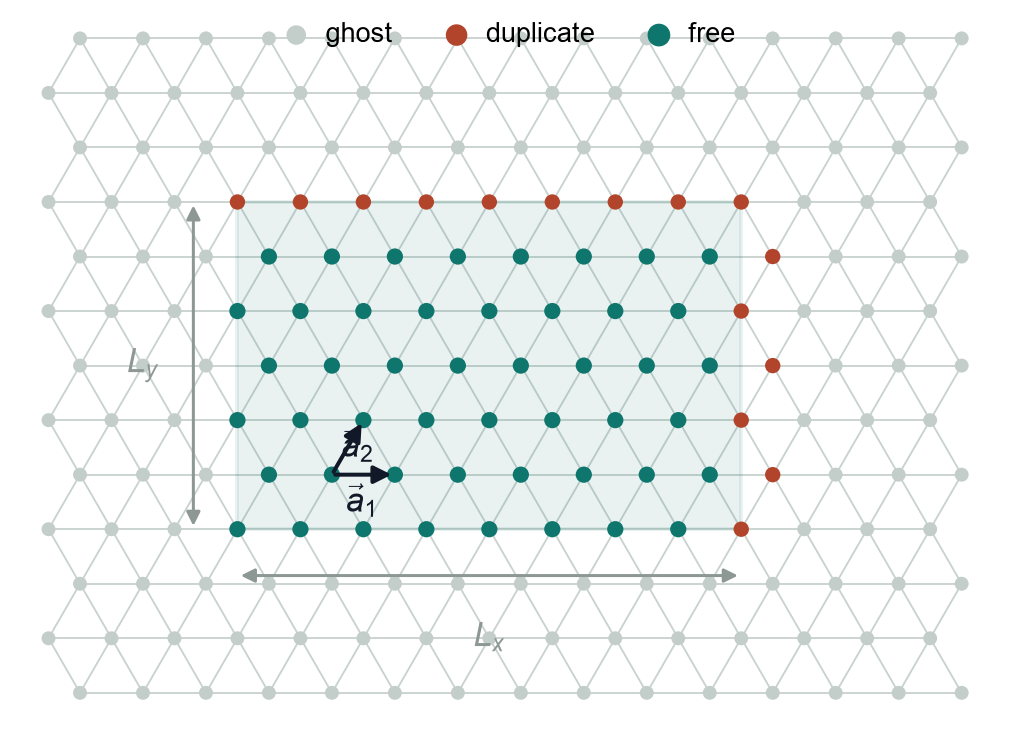

In [6]:
def draw_lattice(ax, n_face_x=14, n_face_y=12, ghost=3, cell=1.0):
    """The zig-zag mesh, and which of its vertices are free coordinates."""
    nx, ny = n_face_x + 1, n_face_y + 1
    tx, ty = n_face_x - 2 * ghost, n_face_y - 2 * ghost
    dx, dy = cell, cell * np.sqrt(3) / 2

    def pos(i, j):
        return (i * dx + (dx / 2 if j % 2 == 0 else 0.0), j * dy)

    seg = []
    for j in range(ny):
        for i in range(nx):
            p = pos(i, j)
            if i + 1 < nx:
                seg.append((p, pos(i + 1, j)))
            if j + 1 < ny:
                for k in ((i, i + 1) if j % 2 == 0 else (i - 1, i)):
                    if 0 <= k < nx:
                        seg.append((p, pos(k, j + 1)))
    ax.add_collection(LineCollection(seg, colors="#c8d2cf", linewidths=1.1,
                                     zorder=1))

    x0, y0 = pos(ghost, ghost)
    ax.add_patch(Rectangle((x0, y0), tx * dx, ty * dy, facecolor=TEAL,
                           alpha=0.09, edgecolor=TEAL, linewidth=2.4, zorder=2))

    kinds = {"free": [], "duplicate": [], "ghost": []}
    for j in range(ny):
        for i in range(nx):
            inside = ghost <= i < ghost + tx and ghost <= j < ghost + ty
            dup = ((i == ghost + tx and ghost <= j <= ghost + ty) or
                   (j == ghost + ty and ghost <= i <= ghost + tx))
            kinds["free" if inside else "duplicate" if dup else "ghost"].append(pos(i, j))
    for key, colour, size in (("ghost", "#c3cecb", 70),
                              ("duplicate", BRICK, 85),
                              ("free", TEAL, 95)):
        p = np.array(kinds[key])
        ax.scatter(p[:, 0], p[:, 1], s=size, c=colour, zorder=3,
                   edgecolors="none", label=key)

    bi, bj = ghost + 1, ghost + 1
    b = pos(bi, bj)
    for tgt, name, off in (((bi + 1, bj), r"$\vec a_1$", (-0.02, -0.42)),
                           ((bi + 1, bj + 1), r"$\vec a_2$", (0.16, 0.02))):
        t = pos(*tgt)
        ax.annotate("", xy=t, xytext=b,
                    arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=2.4,
                                    mutation_scale=22))
        ax.text((b[0] + t[0]) / 2 + off[0], (b[1] + t[1]) / 2 + off[1], name,
                color=INK, fontsize=20, ha="center", va="center")

    ax.annotate("", xy=(x0 + tx * dx, y0 - 0.85 * dy), xytext=(x0, y0 - 0.85 * dy),
                arrowprops=dict(arrowstyle="<|-|>", color=GREY, linewidth=1.8))
    ax.text(x0 + tx * dx / 2, y0 - 1.7 * dy, r"$L_x$", ha="center", va="top",
            color=GREY, fontsize=20)
    ax.annotate("", xy=(x0 - 0.7 * dx, y0 + ty * dy), xytext=(x0 - 0.7 * dx, y0),
                arrowprops=dict(arrowstyle="<|-|>", color=GREY, linewidth=1.8))
    ax.text(x0 - 1.25 * dx, y0 + ty * dy / 2, r"$L_y$", ha="right", va="center",
            color=GREY, fontsize=20)

    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.autoscale_view()
    ax.margins(0.04)


fig, ax = plt.subplots(figsize=(11.0, 6.4))
draw_lattice(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), ncols=3,
          markerscale=1.4, handletextpad=0.3, columnspacing=1.6)
plt.tight_layout()
plt.show()

The red column zig-zags across the right edge of the box because the offset
rows put it half a cell further out: those points sit at $x_0+L_x+d_x/2$, which
wraps to the leftmost column. The row count of the tile is forced even, and
that is exactly what makes the zig-zag close up under the $L_y$ translation.

---
## 2. The transform on a zig-zag lattice

Tile vertex $(p,s)$, with $p = 0\ldots N_x-1$ and $s = 0\ldots N_y-1$, sits at

$$\mathbf r_{p,s} \;=\; \bigl(p\,d_x + \tfrac12 d_x\,\epsilon_s,\; s\,d_y\bigr),
\qquad \epsilon_s\in\{0,1\},\qquad d_y = \tfrac{\sqrt3}{2}d_x$$

where $\epsilon_s = 1$ on the rows that carry the zig-zag half-cell offset
(consult figure above). Specifically, both

$$\epsilon_s = \tfrac12\bigl(1-(-1)^s\bigr)$$

and 

$$\epsilon_s = \tfrac12\bigl(1 - e^{-\pi i s}\bigr)$$

are valid representations. Since $s$ in a non-negative integer.

The tile repeats under $L_x = N_x d_x$ and $L_y = N_y d_y$ — $N_y$ even is
exactly what makes the zig-zag close up under $L_y$ — so the periodicity is
rectangular even though the lattice is triangular, and the allowed wavevectors
are the plain rectangular set

$$\mathbf q_{\mathbf n} \;=\; 2\pi\left(\frac{n_x}{L_x},\, \frac{n_y}{L_y}\right),
\qquad -\tfrac{N_x}{2}\le n_x<\tfrac{N_x}{2},\quad
-\tfrac{N_y}{2}\le n_y<\tfrac{N_y}{2}$$


### Factorizing with the extra zig-zag drift term

Substituting $\mathbf r_{p,s}$ and using
$q_x p\,d_x = 2\pi n_x p/N_x$, $q_y s\,d_y = 2\pi n_y s/N_y$:

$$H(\mathbf q)\;=\;\sum_s e^{-2\pi i n_y s/N_y}\;
\underbrace{e^{-i\theta\,\epsilon_s}}_{\text{half-cell phase}}\;
\underbrace{\sum_p h_{p,s}\, e^{-2\pi i n_x p/N_x}}_{\text{FFT along }x},
\qquad \theta \;\equiv\; \frac{q_x d_x}{2} \;=\; \frac{\pi n_x}{N_x}$$

An FFT along $x$, a diagonal factor, an FFT along $y$ — the three lines of
`tile_fft2`. The middle factor is the entire correction, and `np.fft.fft2`
is the same expression with it set to 1.

### Be careful that $n_x$ must be clear and not period-ambiguous due to the zig-zag offset

The row transform cannot tell $n_x$ from $n_x + N_x$: both give the same
column of the $x$-FFT. The half-cell phase can, because

$$e^{-i\pi (n_x+N_x)/N_x} \;=\; -\,e^{-i\pi n_x/N_x}$$

### What dropping the phase actually does

Substitute in the function form of $\epsilon_s$ Then

$$e^{-i\theta\epsilon_s}\;=\;e^{-i\theta/2}
\left[\cos\tfrac\theta2 \;+\; i\,(-1)^s \sin\tfrac\theta2\right]$$

and multiplying a row index by $(-1)^s$ before the $y$-transform is a shift of
$n_y$ by $N_y/2$. So the true and naive transforms mix in pairs:

$$H_{\mathrm{true}}(n_x,n_y)\;=\;e^{-i\theta/2}\Bigl[
\cos\tfrac\theta2\,H_{\mathrm{naive}}(n_x,n_y)\;+\;
i\sin\tfrac\theta2\,H_{\mathrm{naive}}(n_x,n_y+\tfrac{N_y}{2})\Bigr]$$



### The rest of the reduction, in the same terms

**Normalisation.** `np.fft` returns
$H_{\mathbf q} = \sum_j h_j e^{-i\mathbf q\cdot\mathbf r_j} = N h_{\mathbf q}$
with $N = N_xN_y$, while equation (1) is written for $h_{\mathbf q}$. So
$\langle|h_q|^2\rangle = \langle|H_q|^2\rangle/N^2$ — `power_spectrum`, and the
`/(lat.nx * lat.ny) ** 2` in `block_spectrum` below. Skipping it leaves the
slope right and $\kappa_c$ wrong by $N^2$.

**Folding to the Brillouin zone.** A discrete mode is not one wavevector but
the whole family $\mathbf q + \mathbf G$, and the continuum formula refers to
the shortest member of it. `q_grid` therefore minimises $|\mathbf q +
m_1\mathbf g_1 + m_2\mathbf g_2|$ over the nine nearest images, with the
reciprocal basis dual to $\mathbf a_1 = (d_x, 0)$, $\mathbf a_2 = (d_x/2, d_y)$:

$$\mathbf g_1 = \left(\frac{2\pi}{d_x},\, -\frac{\pi}{d_y}\right),\qquad
\mathbf g_2 = \left(0,\, \frac{2\pi}{d_y}\right),\qquad
\mathbf g_i\cdot\mathbf a_j = 2\pi\,\delta_{ij}$$

Near the zone boundary the rectangular fundamental domain is not the shortest
choice, which is where this changes the answer.

**The limit mask.** The membrane is the limit surface, $h^S = M h^C$, and for a
valence-6 vertex $M$ is $\tfrac12$ on the vertex and $\tfrac1{12}$ on each of
its six neighbours. On a Bravais lattice that is a convolution, so it is
diagonal in $\mathbf q$ with symbol

$$m(\mathbf q) \;=\; \tfrac12 + \tfrac16\bigl[\cos(\mathbf q\cdot\mathbf a_1)
+ \cos(\mathbf q\cdot\mathbf a_2) + \cos(\mathbf q\cdot\mathbf a_3)\bigr],
\qquad \mathbf a_3 = \mathbf a_2 - \mathbf a_1$$

1 at long wavelength, about $\tfrac14$ at the zone corner. `limit_mask_symbol`
does not hard-code that expression: it applies the mask to a delta and divides
the transforms, so the closed form above is a check on the code rather than
the code itself. `limit_surface_from_control` applies the same mask with
periodic wrap — which is why the row parity matters there too, an offset row's
partners in the rows above and below being columns $(i, i{+}1)$ and a
non-offset row's $(i{-}1, i)$.

**The autocorrelation.** `mode_autocorrelation` is Wiener–Khinchin along the
time axis — one FFT of each mode's series, times its conjugate, back — with
the $1/(n-\tau)$ unbiased normalisation and the frame mean removed first, so a
mode that never decorrelates within the run reads as a slow decay rather than
a constant offset.

**The rate.** `relaxation_rate` does not fit an exponential to a noisy tail. It
integrates: with $k$ the first lag at which $C_q \le 1/e$,

$$\tau_q \;=\; \frac{\int_0^{k\,\Delta t} C_q(\tau)\,\mathrm d\tau}{1 - C_q(k)},
\qquad \Gamma = 1/\tau_q$$

which is *exact* for a single exponential, since
$\int_0^{t}e^{-\tau'/\tau}\mathrm d\tau' = \tau\,(1-e^{-t/\tau})$, and far
steadier when the tail is noisy. The two guards around it — a correlation time
of at least a few output intervals, and a block of at least $\sim\!25$ of them
— are what make an unresolvable mode come back as `nan` instead of as the
sampling rate.

---
## 3. Loading a trajectory

`meshpointinput.csv` holds the Loop **control** points, one frame per line.
The membrane itself is the limit surface, so `limit_surface_from_control`
applies the valence-6 Loop limit mask ($\tfrac12$ on the vertex, $\tfrac1{12}$
on each of its six neighbours) with periodic wrap.

Before measuring anything, check the run has a stationary state to measure.

In [7]:
RUN = RUNS / "pure_a"        # 100 nm box, no area elasticity, all fixes on
lat = ms.lattice_from_params(RUN / "input.params")

par = {}
for line in open(RUN / "input.params"):
    if "=" in line and not line.strip().startswith("#"):
        k, v = line.split("=", 1)
        par[k.strip()] = v.split("#")[0].strip()

KC_IN = float(par["kcMembraneBending"])
DT = float(par["timeStep"])
DIFF = float(par["diffConst"])
INTERVAL = int(par.get("meshpointOutputInterval", 1))
DT_FRAME = DT * INTERVAL
A_CELL = lat.area / (lat.nx * lat.ny)

print(lat.describe())
print(f"kc = {KC_IN} pN.nm ({KC_IN/KBT:.0f} kT), mu_S = "
      f"{par['usMembraneStretching']} pN/nm")
print(f"dt = {DT} us, D = {DIFF} nm^2/us, frame every {INTERVAL} steps "
      f"= {DT_FRAME} us")

mesh 21 x 25 vertices (nFace 20 x 24), cell 5 x 4.33013 nm
periodic tile 14 x 18 = 252 vertices, Lx = 70 nm, Ly = 77.9423 nm, A = 5455.96 nm^2
kc = 83.4 pN.nm (20 kT), mu_S = 0.0 pN/nm
dt = 0.002 us, D = 1.0 nm^2/us, frame every 100 steps = 0.2 us


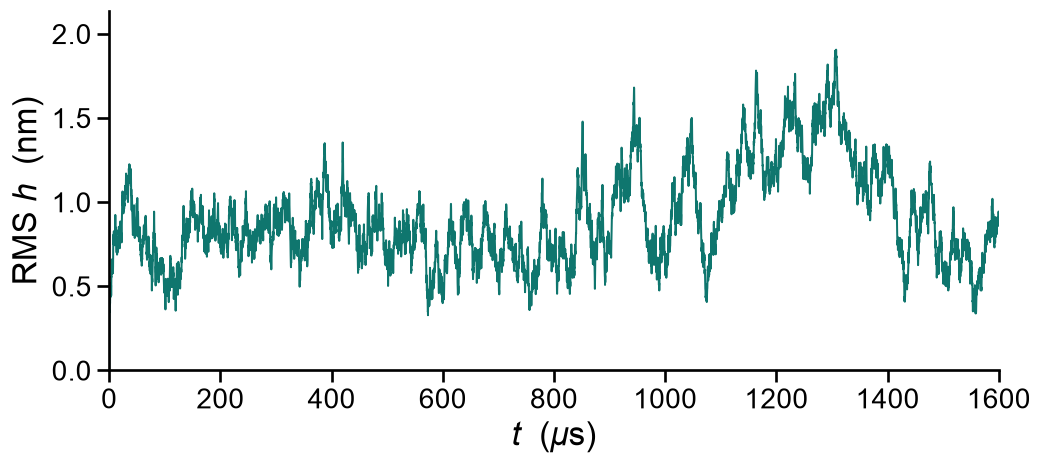

8001 frames = 1600 us; discarding 1600, analysing 6401 (1280 us)


In [8]:
z = ms.read_tile_heights(RUN / "meshpointinput.csv", lat)   # control points
h = ms.limit_surface_from_control(z, lat)                   # the membrane
t = np.arange(h.shape[0]) * DT_FRAME

rms = h.reshape(len(h), -1)
rms = np.sqrt(((rms - rms.mean(axis=1, keepdims=True)) ** 2).mean(axis=1))

fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(t, rms, lw=1.2, color=TEAL)
ax.set_xlabel(r"$t$  ($\mu$s)")
ax.set_ylabel(r"RMS $h$  (nm)")
ax.set_xlim(0, t[-1])
ax.set_ylim(0, max(2.0, rms.max() * 1.12))
plt.tight_layout()
plt.show()

BURN = len(h) // 5
h_eq = h[BURN:]
print(f"{h.shape[0]} frames = {t[-1]:.0f} us; discarding {BURN}, "
      f"analysing {len(h_eq)} ({len(h_eq)*DT_FRAME:.0f} us)")

## plot q over time

---
## 4. The spectrum: recovering $q^{-4}$

`tile_fft2` is the exact DFT on the true vertex positions — an FFT along $x$,
the half-cell phase $e^{-iq_x d_x/2}$ on the offset rows, an FFT along $y$.
`q_grid` returns the matching wavevectors from the reciprocal lattice with the
signed mode number. `power_spectrum` divides by $N^2$, because `fft2` returns
$H_{\mathbf q} = N h_{\mathbf q}$ in the convention above.

Each surviving mode is one datapoint. Its error bar is the standard error of
$\langle|h_{\mathbf q}|^2\rangle$ over eight equal blocks of that mode's own time
series, so a mode the run has barely relaxed carries a visibly larger bar.

In [9]:
def block_spectrum(h_frames, lat, nblock=NBLOCK):
    """Per-mode <|h_q|^2> and its standard error over equal time blocks."""
    H = ms.tile_fft2(h_frames, lat)
    n = len(h_frames)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    per = np.array([np.mean(np.abs(H[a:b]) ** 2, axis=0)
                    for a, b in zip(edges[:-1], edges[1:])])
    per /= (lat.nx * lat.ny) ** 2
    return per.mean(axis=0), per.std(axis=0, ddof=1) / np.sqrt(nblock)


qx, qy, q2d = ms.q_grid(lat)
S2d, S2d_err = block_spectrum(h_eq, lat)

keep = unique_modes(lat)
qv, Sv, Ev = q2d[keep], S2d[keep], S2d_err[keep]
order = np.argsort(qv)
qv, Sv, Ev = qv[order], Sv[order], Ev[order]
win = qv * lat.d_face_x <= QDX_MAX

# log-log fit inside the continuum window, weighted by each mode's own error
wgt = Sv[win] / np.maximum(Ev[win], 1e-30)
slope, icept = np.polyfit(np.log10(qv[win]), np.log10(Sv[win]), 1, w=wgt)

# and the physical two-parameter fit, on the same modes
kc_fit, sigma_fit = ms.fit_kc_sigma(qv[win], Sv[win], lat.area, KBT)

print(f"{len(qv)} independent modes, {win.sum()} inside q*dx <= pi/2")
print(f"log-log slope   = {slope:+.3f}          (want -4)")
print(f"fitted kc       = {kc_fit:7.2f} pN.nm   ({kc_fit/KBT:.1f} kT; "
      f"input {KC_IN}, {KC_IN/KBT:.0f} kT)")
print(f"fitted sigma    = {sigma_fit:7.3f} pN/nm  (run has no area elasticity)")

127 independent modes, 22 inside q*dx <= pi/2
log-log slope   = -3.947          (want -4)
fitted kc       =   90.96 pN.nm   (21.8 kT; input 83.4, 20 kT)
fitted sigma    =   0.019 pN/nm  (run has no area elasticity)


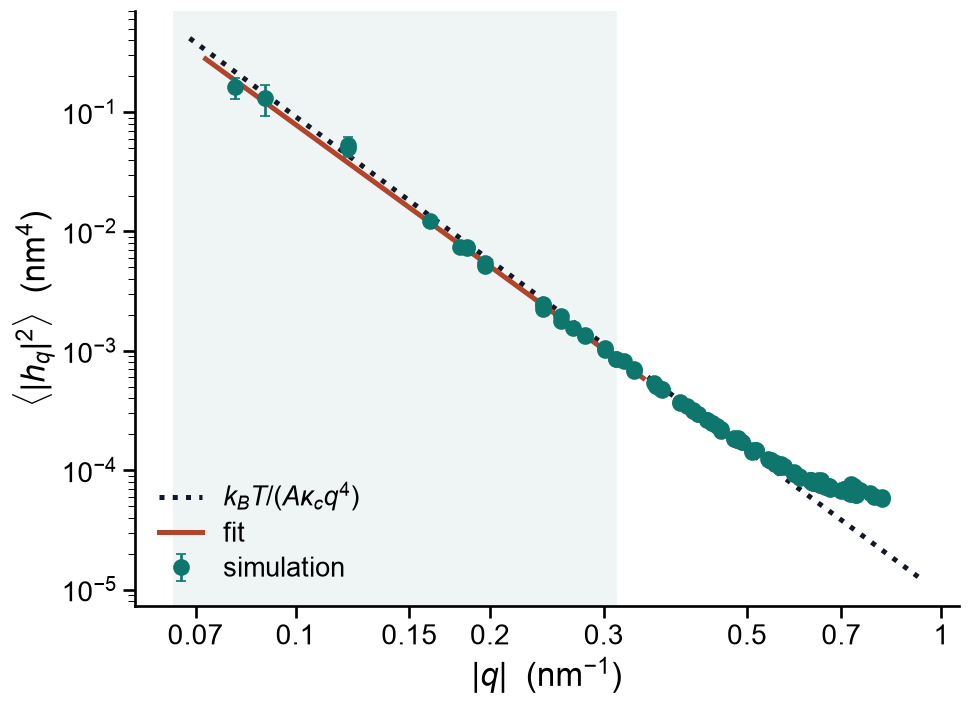

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 6.2))

qq = np.logspace(np.log10(qv.min() * 0.85), np.log10(qv.max() * 1.15), 200)
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), ":", color=INK, lw=3.0,
        zorder=2, label=r"$k_BT/(A\kappa_c q^4)$")

qf = np.logspace(np.log10(qv[win].min() * 0.9), np.log10(qv[win].max() * 1.1), 50)
ax.plot(qf, 10 ** icept * qf ** slope, "-", color=BRICK, lw=3.0, zorder=3,
        label="fit")

ax.errorbar(qv, Sv, yerr=Ev, fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.6, lw=0, zorder=4, label="simulation")

ax.axvspan(qv.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07,
           lw=0, zorder=0)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\langle |h_q|^2 \rangle$  (nm$^4$)")
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

The shaded band is the continuum window, $q\,d_x \le \pi/2$; the fit (red) is
over the modes inside it, the dotted black line is
$k_BT/(A\kappa_c q^4)$ evaluated with the $\kappa_c$ that went **into** the run
— not a fit, so its intercept is a prediction as well as its slope.

Points lift above the dotted line at the right-hand edge because the Loop limit
surface is measurably *softer* than a smooth sheet there: the quartic box
spline no longer resolves the curvature. That is not a fudge. It is measured
statically by `tests/test_continuum_limit.cpp`, which puts an exact plane wave
of known amplitude on the control net and reads the bending energy the
production code returns — no simulation involved. The stiffness referred to the
limit surface is $1.000$ of $A\kappa_c q^4$ at long wavelength, $0.995$ at
$q d_x = \pi/2$, $0.975$ at $2.0$ and $0.70$ at $3.2$, and it depends on
$q\,d_x$ alone, so it is a property of the mesh resolution rather than the box.

That is where the window comes from. $q\,d_x = \pi$ is the Nyquist wavevector of
the mesh spacing, so $\pi/2$ is half of it — four cells per wavelength — and
the discretisation error there is half a per cent. Note this is *not* the
cutoff quoted for lipid-bilayer simulations (Brandt et al., *Biophys J* **100**,
2104, put it near $0.7\ \mathrm{nm^{-1}}$ for DMPC): theirs is molecular, set by
the density structure factor and by thickness and protrusion modes. SLIMED has
no thickness and no protrusions, so nothing physical limits it and only the
mesh does.

---
## 5. The $\kappa_c$ plot

Dividing the measured spectrum back through the law gives an effective bending
modulus per mode,

$$\kappa_c^{\mathrm{eff}}(q) \;=\; \frac{k_BT}{A\,q^4\,\langle|h_q|^2\rangle}$$

flat at the input $\kappa_c$ wherever the law holds. This is a far more
sensitive read than the log–log slope: a 10% amplitude error is invisible over
four decades of $\langle|h_q|^2\rangle$ and obvious here.

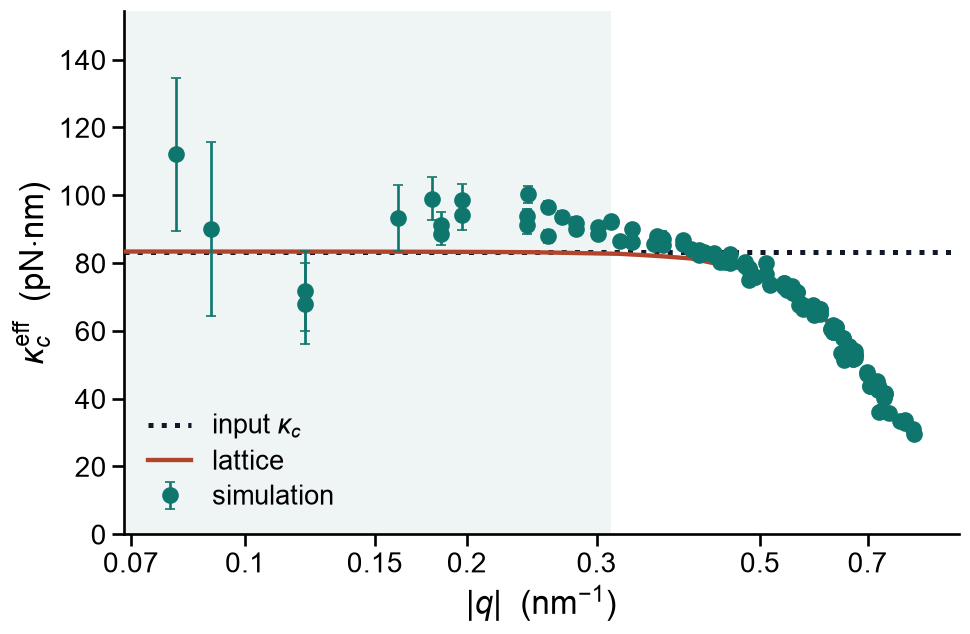

mean kc inside the window: 91.6 +/- 1.9 pN.nm (input 83.4)


In [11]:
kc_eff = KBT / (lat.area * qv ** 4 * Sv)
kc_err = kc_eff * (Ev / Sv)

fig, ax = plt.subplots(figsize=(8.4, 5.6))
ax.axvspan(qv.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07,
           lw=0, zorder=0)
ax.axhline(KC_IN, color=INK, lw=3.0, ls=":", zorder=2, label=r"input $\kappa_c$")
qm = qq[qq * lat.d_face_x <= FORM_FACTOR[-1, 0]]   # only where it was measured
ax.plot(qm, KC_IN * form_factor(qm, lat.d_face_x), "-", color=BRICK, lw=2.6,
        zorder=3, label="lattice")
ax.errorbar(qv, kc_eff, yerr=kc_err, fmt="o", ms=9, mfc=TEAL, mec=TEAL,
            ecolor=TEAL, elinewidth=1.6, lw=0, zorder=4, label="simulation")

ax.set_xscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\kappa_c^{\mathrm{eff}}$  (pN$\cdot$nm)")
ax.set_xlim(qv.min() * 0.85, qv.max() * 1.15)
ax.set_ylim(0, KC_IN * 1.85)
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"mean kc inside the window: {kc_eff[win].mean():.1f} +/- "
      f"{kc_eff[win].std(ddof=1)/np.sqrt(win.sum()):.1f} pN.nm "
      f"(input {KC_IN})")

The red curve is not fitted either: it is the input $\kappa_c$ times the
statically measured lattice form factor, drawn only over the range that
measurement covers. It accounts for most of the roll-off outside the window;
the last few modes fall further still, which is the corner of the Brillouin
zone where the transform itself is marginal and where no fit should go anyway.

### How much trajectory does this need?

The lowest-$q$ mode relaxes as $q^{-4}$, so it converges last; a run that has
not sampled it reads *low* and drags the slope towards zero. Refitting from
growing prefixes of the same trajectory shows where it settles.

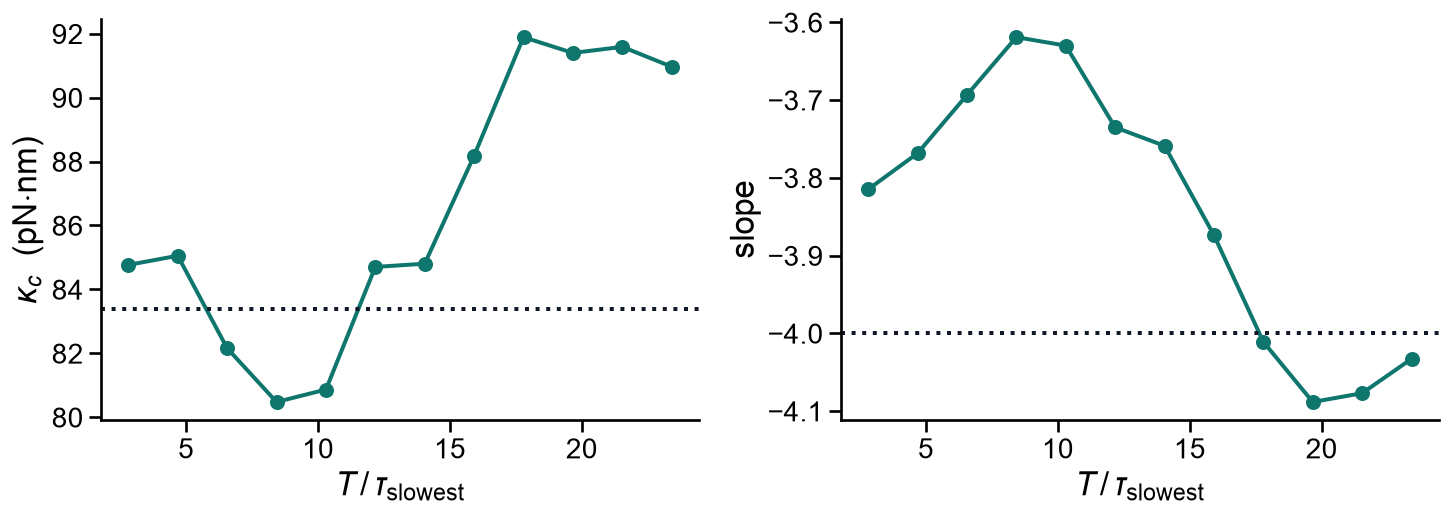

slowest mode: tau = 55 us; analysed window is 23 of those


In [12]:
fracs = np.linspace(0.12, 1.0, 12)
rows = []
for f in fracs:
    n = int(len(h_eq) * f)
    Sf, _ = block_spectrum(h_eq[:n], lat, nblock=4)
    sv = Sf[keep][order]
    kc_f, _ = ms.fit_kc_sigma(qv[win], sv[win], lat.area, KBT)
    sl = np.polyfit(np.log10(qv[win]), np.log10(sv[win]), 1)[0]
    rows.append((n * DT_FRAME, sl, kc_f))
rows = np.array(rows)

tau_slow = KBT / (DIFF * A_CELL * KC_IN * qv.min() ** 4)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
for ax, col, ref, lab in ((axes[0], 2, KC_IN, r"$\kappa_c$  (pN$\cdot$nm)"),
                          (axes[1], 1, -4.0, "slope")):
    ax.plot(rows[:, 0] / tau_slow, rows[:, col], "o-", color=TEAL, ms=8, lw=2.4)
    ax.axhline(ref, color=INK, lw=2.4, ls=":")
    ax.set_xlabel(r"$T\,/\,\tau_{\mathrm{slowest}}$")
    ax.set_ylabel(lab)
plt.tight_layout()
plt.show()

print(f"slowest mode: tau = {tau_slow:.0f} us; analysed window is "
      f"{len(h_eq)*DT_FRAME/tau_slow:.0f} of those")

---
## 6. What area elasticity does

The shipped `input.params` sets `usMembraneStretching` = $\mu_S$ = 250 pN/nm
against a reference area pinned to the *flat* starting area. Fluctuations buy
excess area the constraint pulls back, so a real tension develops and the
spectrum crosses over to $q^{-2}$ below $q^{*}=\sqrt{\sigma/\kappa_c}$. No
analysis can recover $q^{-4}$ from that.

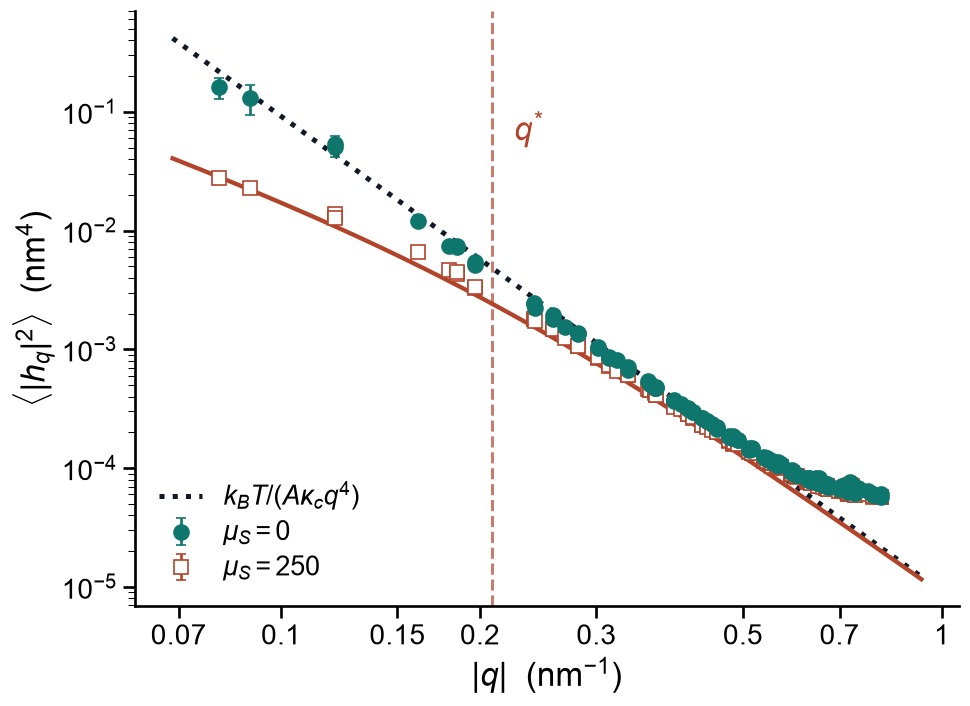

fitted sigma = 3.63 pN/nm, crossover q* = 0.209 /nm, slope over the window = -2.79


In [13]:
TENSION = RUNS / "tension"
lat_t = ms.lattice_from_params(TENSION / "input.params")
assert (lat_t.nx, lat_t.ny) == (lat.nx, lat.ny)

zt = ms.read_tile_heights(TENSION / "meshpointinput.csv", lat_t)
ht = ms.limit_surface_from_control(zt, lat_t)[len(zt) // 5:]
St2d, Et2d = block_spectrum(ht, lat_t)
Svt, Evt = St2d[keep][order], Et2d[keep][order]
kct, sigt = ms.fit_kc_sigma(qv[win], Svt[win], lat.area, KBT)
q_star = np.sqrt(max(sigt, 0) / KC_IN)

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), ":", color=INK, lw=3.0,
        zorder=2, label=r"$k_BT/(A\kappa_c q^4)$")
ax.plot(qq, KBT / (lat.area * (KC_IN * qq ** 4 + sigt * qq ** 2)), "-",
        color=BRICK, lw=2.6, zorder=2)
ax.errorbar(qv, Sv, yerr=Ev, fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.6, lw=0, zorder=4, label=r"$\mu_S = 0$")
ax.errorbar(qv, Svt, yerr=Evt, fmt="s", ms=8, mfc="white", mec=BRICK,
            ecolor=BRICK, elinewidth=1.6, lw=0, zorder=3, label=r"$\mu_S = 250$")
ax.axvline(q_star, color=BRICK, lw=1.8, ls="--", alpha=0.7, zorder=1)
ax.text(q_star * 1.08, Sv.max() * 0.35, r"$q^{*}$", color=BRICK, fontsize=20)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\langle |h_q|^2 \rangle$  (nm$^4$)")
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"fitted sigma = {sigt:.2f} pN/nm, crossover q* = {q_star:.3f} /nm, "
      f"slope over the window = "
      f"{np.polyfit(np.log10(qv[win]), np.log10(Svt[win]), 1)[0]:+.2f}")

In [26]:
TENSION = RUNS / "tension"
US_IN = 250.0
lat_t = ms.lattice_from_params(TENSION / "input.params")
assert (lat_t.nx, lat_t.ny) == (lat.nx, lat.ny)

zt = ms.read_tile_heights(TENSION / "meshpointinput.csv", lat_t)
ht = ms.limit_surface_from_control(zt, lat_t)[len(zt) // 5:]
St2d, Et2d = block_spectrum(ht, lat_t)
Svt, Evt = St2d[keep][order], Et2d[keep][order]
kct, sigt = ms.fit_kc_sigma(qv[win], Svt[win], lat.area, KBT)
q_star = np.sqrt(max(sigt, 0) / KC_IN)


print("KBT * US_IN / (4 * np.pi * KC_IN) * np.log(lat.n_face_x):", 
      KBT * US_IN / (4 * np.pi * KC_IN) * np.log(lat.n_face_x))
print("sigma_fit:", sigt)



print(f"fitted sigma = {sigt:.2f} pN/nm, crossover q* = {q_star:.3f} /nm, "
      f"slope over the window = "
      f"{np.polyfit(np.log10(qv[win]), np.log10(Svt[win]), 1)[0]:+.2f}")

KBT * US_IN / (4 * np.pi * KC_IN) * np.log(lat.n_face_x): 2.9799099969752474
sigma_fit: 3.6267868506727554
fitted sigma = 3.63 pN/nm, crossover q* = 0.209 /nm, slope over the window = -2.79


---
## 7. Time decorrelation: $\langle h_q(t)\,h^*_q(t+\tau)\rangle$

Each mode is an Ornstein–Uhlenbeck process, so its autocorrelation is a single
exponential,

$$C_q(\tau)\;=\;\frac{\langle h_{\mathbf q}(t)\,h^*_{\mathbf q}(t+\tau)\rangle}
{\langle|h_{\mathbf q}|^2\rangle}\;=\;e^{-\Gamma(q)\,\tau}$$

and **all** the information about the solvent is in $\Gamma(q)$ — the static
spectrum above has no mobility in it at all. Two candidate laws:

| | mobility | rate |
| --- | --- | --- |
| free draining (what SLIMED implements) | $\Lambda = Da/k_BT$, a per-vertex scalar | $\Gamma = \Lambda\,\kappa_c q^4$ |
| Oseen / Zimm hydrodynamics | $\Lambda(q) = 1/4\eta q$ | $\Gamma = \kappa_c q^3/4\eta$ |

$\tau_q$ spans four orders of magnitude across the zone, so no single output
interval resolves all of it: a trajectory written every 100 steps cannot time a
mode that decorrelates in three, and one written every step is too short to
time the slowest. Both runs are used, each over the part of the band it
resolves.

In [15]:
def load_frames(run_dir, start=0, max_frames=None, burn_frac=0.2):
    lat_ = ms.lattice_from_params(run_dir / "input.params")
    p = {}
    for line in open(run_dir / "input.params"):
        if "=" in line and not line.strip().startswith("#"):
            k, v = line.split("=", 1)
            p[k.strip()] = v.split("#")[0].strip()
    dtf = float(p["timeStep"]) * int(p.get("meshpointOutputInterval", 1))
    zz = ms.read_tile_heights(run_dir / "meshpointinput.csv", lat_,
                              start=start, max_frames=max_frames)
    hh = ms.limit_surface_from_control(zz, lat_)[int(len(zz) * burn_frac):]
    return hh, dtf


# long run for the slow modes, every-step run for the fast ones
h_slow, dt_slow = load_frames(RUN)
h_fast, dt_fast = load_frames(RUNS / "fast_test", burn_frac=0.25)
print(f"long : {len(h_slow):6d} frames x {dt_slow} us = {len(h_slow)*dt_slow:.0f} us")
print(f"short: {len(h_fast):6d} frames x {dt_fast} us = {len(h_fast)*dt_fast:.0f} us")

long :   6401 frames x 0.2 us = 1280 us
short:  45001 frames x 0.002 us = 90 us


In [16]:
# Only trust a mode the record resolves at BOTH ends: its correlation time must
# span several output intervals (or the sampling rate is what is measured) and
# fit many times into the block (or subtracting the block mean eats the
# signal).  Everything else comes back as nan and simply does not plot.
MIN_LAGS = 3.0        # tau >= 3 output intervals
MIN_SAMPLES = 25.0    # block >= 25 correlation times


def block_rates(h_frames, lat, dtf, nblock=NBLOCK):
    """Per-mode Gamma and its standard error over equal time blocks."""
    n = len(h_frames)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    per = np.full((nblock, lat.ny, lat.nx), np.nan)
    for b, (a, c) in enumerate(zip(edges[:-1], edges[1:])):
        nb = c - a
        acf = ms.mode_autocorrelation(ms.tile_fft2(h_frames[a:c], lat),
                                      max_lag=max(4, nb // 3))
        for iy in range(lat.ny):
            for ix in range(lat.nx):
                per[b, iy, ix] = ms.relaxation_rate(
                    acf[:, iy, ix], dtf, n_frames=nb,
                    max_tau_fraction=1.0 / MIN_SAMPLES, min_lags=MIN_LAGS)
    cnt = np.isfinite(per).sum(axis=0)
    # A mode no block could time is all-nan; that is the answer, not a warning.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(per, axis=0)
        sem = np.nanstd(per, axis=0, ddof=1) / np.sqrt(np.maximum(cnt, 1))
    mean[cnt < 3] = np.nan
    sem[cnt < 3] = np.nan
    return mean, sem


g_slow, ge_slow = block_rates(h_slow, lat, dt_slow)
g_fast, ge_fast = block_rates(h_fast, lat, dt_fast)
for nm, g in (("long", g_slow), ("short", g_fast)):
    ok = np.isfinite(g)
    band = (f"|q| = {q2d[ok].min():.3f} .. {q2d[ok].max():.3f} nm^-1" if ok.any()
            else "none in the band this record resolves")
    print(f"{nm:>5} run: {ok.sum():3d}/{(q2d>0).sum()} modes resolved, {band}")

 long run:  20/251 modes resolved, |q| = 0.161 .. 0.258 nm^-1
short run: 231/251 modes resolved, |q| = 0.241 .. 0.809 nm^-1


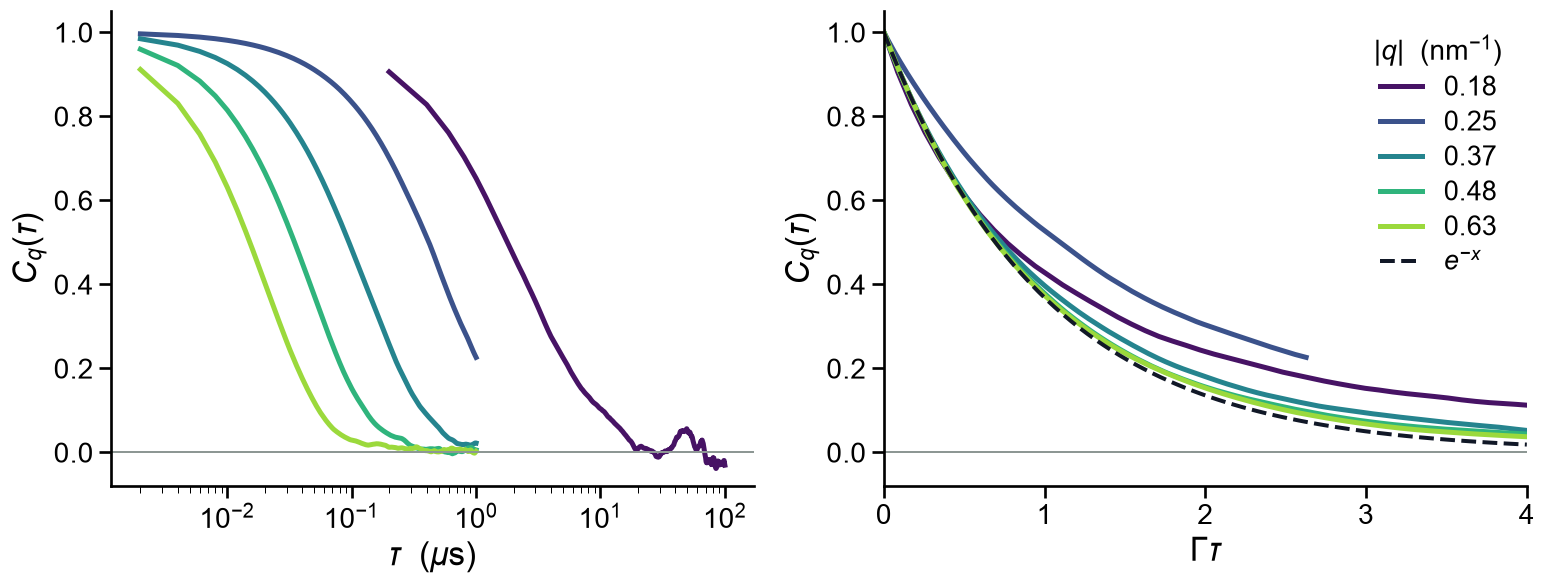

In [17]:
def shell_acf(h_frames, lat, dtf, lo, hi, max_lag=500):
    """Autocorrelation averaged over the modes in one |q| shell."""
    m = (q2d > lo) & (q2d <= hi)
    acf = ms.mode_autocorrelation(ms.tile_fft2(h_frames, lat),
                                  max_lag=min(max_lag, len(h_frames) // 3))
    return acf[:, m].mean(axis=1), q2d[m].mean()


shells = [(0.155, 0.20, h_slow, dt_slow, g_slow),
          (0.24,  0.27, h_fast, dt_fast, g_fast),
          (0.34,  0.39, h_fast, dt_fast, g_fast),
          (0.45,  0.50, h_fast, dt_fast, g_fast),
          (0.60,  0.65, h_fast, dt_fast, g_fast)]
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, len(shells)))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))
for (lo, hi, hh, dtf, grid), colour in zip(shells, cmap):
    with warnings.catch_warnings():   # a shell no block could time is all-nan
        warnings.simplefilter("ignore", RuntimeWarning)
        rate = np.nanmean(grid[(q2d > lo) & (q2d <= hi)])
    if not np.isfinite(rate):
        continue
    c, qm = shell_acf(hh, lat, dtf, lo, hi)
    tau = np.arange(len(c)) * dtf
    axes[0].plot(tau[1:], c[1:], color=colour, lw=3.0, label=f"{qm:.2f}")
    axes[1].plot(tau * rate, c, color=colour, lw=3.0, label=f"{qm:.2f}")

x = np.linspace(0, 4, 80)
axes[1].plot(x, np.exp(-x), "--", color=INK, lw=2.4, label=r"$e^{-x}$")
axes[1].set_xlim(0, 4)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\tau$  ($\mu$s)")
axes[1].set_xlabel(r"$\Gamma\tau$")
for ax in axes:
    ax.axhline(0, color=GREY, lw=1.2)
    ax.set_ylabel(r"$C_q(\tau)$")
    ax.set_ylim(-0.08, 1.05)
axes[1].legend(title=r"$|q|$  (nm$^{-1}$)", loc="upper right")
plt.tight_layout()
plt.show()

Single exponentials that collapse onto $e^{-x}$ once time is rescaled by each
shell's own rate — which is what an overdamped mode should do, and a check that
nothing in the sampling is distorting the correlation. The rates themselves are
the interesting part.

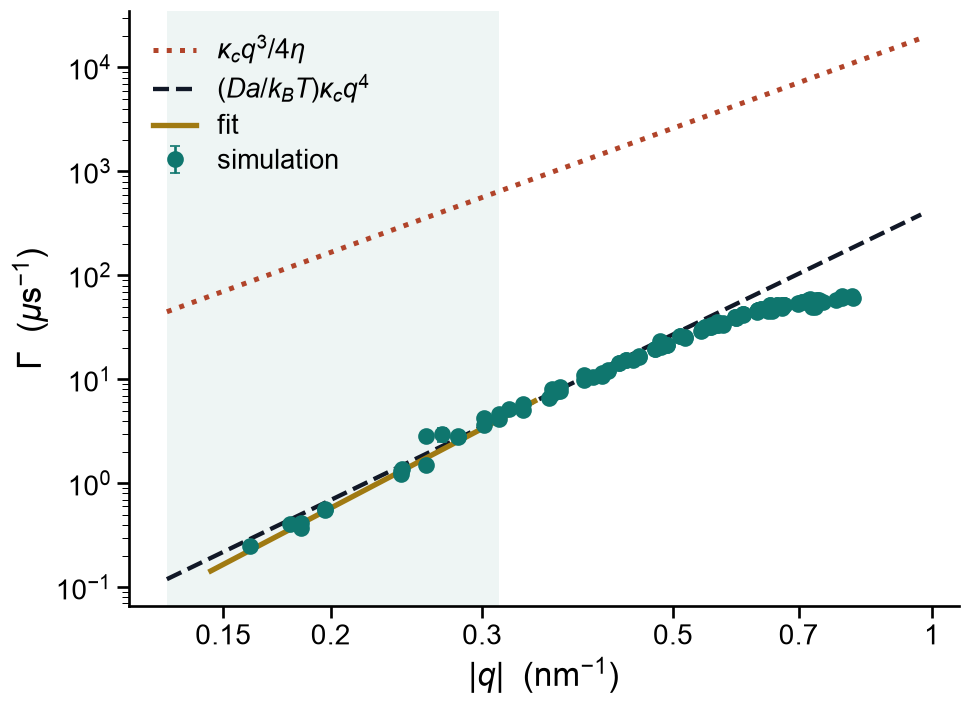

123 modes, |q| = 0.161 .. 0.809 nm^-1
log-log slope inside the window : +4.34   (+4 free draining, +3 Oseen)
median Gamma / free draining    : 0.91
median Gamma / Oseen            : 4.5e-03


In [18]:
LAMBDA = DIFF * A_CELL / KBT          # nm^3/(pN us) -- the code's own mobility
ETA = 1.0e-3                          # pN.us/nm^2   (= 1 mPa.s, water)

# one point per independent mode, taken from whichever run resolves it
g_all = np.where(np.isfinite(g_slow), g_slow, g_fast)
ge_all = np.where(np.isfinite(g_slow), ge_slow, ge_fast)
ok = keep & np.isfinite(g_all)
qg, gg, ge = q2d[ok], g_all[ok], ge_all[ok]
o = np.argsort(qg)
qg, gg, ge = qg[o], gg[o], ge[o]

gwin = qg * lat.d_face_x <= QDX_MAX
wg = gg[gwin] / np.maximum(ge[gwin], 1e-30)
gslope, gicept = np.polyfit(np.log10(qg[gwin]), np.log10(gg[gwin]), 1, w=wg)

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ql = np.logspace(np.log10(qg.min() * 0.8), np.log10(qg.max() * 1.2), 200)
ax.plot(ql, KC_IN * ql ** 3 / (4 * ETA), ":", color=BRICK, lw=3.0, zorder=2,
        label=r"$\kappa_c q^3/4\eta$")
ax.plot(ql, LAMBDA * KC_IN * ql ** 4, "--", color=INK, lw=2.6, zorder=2,
        label=r"$(Da/k_BT)\kappa_c q^4$")
qfit = np.logspace(np.log10(qg[gwin].min() * 0.9),
                   np.log10(qg[gwin].max() * 1.1), 50)
ax.plot(qfit, 10 ** gicept * qfit ** gslope, "-", color=OCHRE, lw=3.2, zorder=3,
        label="fit")
ax.errorbar(qg, gg, yerr=ge, fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.6, lw=0, zorder=4, label="simulation")
ax.axvspan(qg.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07,
           lw=0, zorder=0)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\Gamma$  ($\mu$s$^{-1}$)")
nice_logx(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

pred = LAMBDA * KC_IN * qg ** 4
oseen = KC_IN * qg ** 3 / (4 * ETA)
print(f"{len(qg)} modes, |q| = {qg.min():.3f} .. {qg.max():.3f} nm^-1")
print(f"log-log slope inside the window : {gslope:+.2f}   "
      "(+4 free draining, +3 Oseen)")
print(f"median Gamma / free draining    : {np.median((gg/pred)[gwin]):.2f}")
print(f"median Gamma / Oseen            : {np.median((gg/oseen)[gwin]):.1e}")

## Tune D so that the Oseen prediction matches the simulation more closely
## which is also a good way to predict D systematically

The fitted exponent is $+4$, the mirror of the $-4$ in the static spectrum:
$\Gamma\propto q^4$ means $\tau_q\propto q^{-4}$. The points sit on the dashed
line, which is drawn from the run's *own* `diffConst`, area per vertex and
`kcMembraneBending` — there is no fitted prefactor in it — and two to three
orders of magnitude below the dotted Oseen line.

That is not a near miss to be tuned away. `DynamicModel::next_step()` displaces
each vertex by $(D\,\mathrm{d}t/k_BT)F_i + \sqrt{2D\,\mathrm{d}t}\,\xi_i$: a
scalar mobility, per vertex, independent of every other vertex. There is no
Oseen tensor, no Rotne–Prager–Yamakawa, no mobility matrix anywhere in the
repository, so $\Gamma\propto q^4$ is what the integrator *is*, and a
$q^{-3}$ decorrelation cannot come out of it however the trajectory is
analysed.

Two things to know before reading any absolute timescale out of this model:

* **`diffConst` is not tied to a solvent.** It is a free per-vertex parameter in
  nm$^2/\mu$s, so absolute relaxation times are arbitrary until it is
  calibrated.
* **The free-draining rate is mesh dependent.** $\Gamma = (Da/k_BT)\kappa_c q^4$
  is proportional to the area per vertex, so refining the mesh at fixed $D$
  slows the dynamics by the refinement factor squared. The quantity to hold
  fixed for mesh-convergent dynamics is the mobility *per unit area*,
  $\Lambda = Da/k_BT$.

For a flat periodic sheet the Oseen mobility is diagonal in Fourier space, so
adding it would not need a dense mobility matrix at all: FFT the nodal force,
multiply by $\Lambda(q)\mathrm{d}t$, add noise of variance
$2k_BT\Lambda(q)\mathrm{d}t/A$ per mode — trivially square-rooted because the
mobility is diagonal, which is the expensive step in real space — and inverse
FFT. `analysis/reference_langevin.py` does exactly that and reproduces both
limbs: identical static spectra, $\Gamma$ exponent $3.84$ with the local
mobility and $2.93$ with Oseen.